## Clustering -- Descriptive Analytics

**Goal:** Group songs into clusters based purely on their audio features -- without using genre labels.

We use two approaches:
- **K-Means**: We specify how many clusters we want. It groups songs by minimising distance to cluster centres.
- **DBSCAN**: No need to specify the number of clusters. It finds dense regions automatically and marks isolated points as noise.

**Key design decision:** We use only the 9 true audio features -- dropping `popularity` (target variable), `duration_ms`, `key`, `mode`, `time_signature` (structural metadata, not sound descriptors), `track_id`, `track_genre`, and `explicit`. This gives meaningfully better cluster quality.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")

All imports successful.


## 1. Feature Selection -- Why Only Audio Features?

**Dropped columns and reasons:**

| Column | Reason for dropping |
|---|---|
| `track_id` | Unique ID -- no musical meaning |
| `track_genre` | Required to drop (no labels during unsupervised learning) |
| `explicit` | Boolean True/False -- not a sound quality |
| `popularity` | **Target variable** for later tasks. Using it here = data leakage. Clusters would split by fame, not sound. |
| `key`, `mode` | Categorical integer codes (0-11), not continuous audio properties |
| `duration_ms` | Song length in ms -- does not describe how it sounds |
| `time_signature` | Mostly 4/4 across all songs -- adds noise with minimal signal |

**Kept features (9 true audio descriptors):**
`danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo`

In [2]:
df = pd.read_csv('tracks2026.csv')

# Fix loudness outlier identified in EDA
df.loc[df['loudness'] > 0, 'loudness'] = np.nan

# Remove fully duplicate rows
df = df.drop_duplicates()

# Save genre labels separately -- used AFTER clustering to evaluate alignment
genre_labels = df['track_genre'].copy()

# 9 audio features only
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

X = df[AUDIO_FEATURES].copy()

print("Features used for clustering:")
print(AUDIO_FEATURES)
print(f"\nDataset shape: {X.shape}")
print(f"\nMissing values per feature:")
print(X.isnull().sum())

Features used for clustering:
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

Dataset shape: (1994, 9)

Missing values per feature:
danceability        40
energy              40
loudness            40
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
dtype: int64


## 2. Preprocessing Pipeline

Two steps chained in a `Pipeline`:

1. **`SimpleImputer(strategy='median')`** -- fills missing values with the column median.
   - Why median (not mean)? Features like `instrumentalness` are heavily skewed. The mean gets pulled by outliers; the median stays representative.

2. **`StandardScaler()`** -- rescales every feature to mean=0, std=1.
   - Why? K-Means and DBSCAN use **distance**. Without scaling, `tempo` (range 51-206) would dominate `danceability` (range 0-1) just because its numbers are bigger. Scaling gives every feature equal weight.

Using a `Pipeline` ensures the same transformations are applied consistently every time.

In [3]:
preprocess_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # Fill NaN with column median
    ('scaler',  StandardScaler())                     # Rescale: mean=0, std=1
])

X_scaled = preprocess_pipeline.fit_transform(X)

print(f"Shape after preprocessing : {X_scaled.shape}")
print(f"Mean of first feature (should be ~0): {X_scaled[:, 0].mean():.4f}")
print(f"Std  of first feature (should be ~1): {X_scaled[:, 0].std():.4f}")

Shape after preprocessing : (1994, 9)
Mean of first feature (should be ~0): -0.0000
Std  of first feature (should be ~1): 1.0000


---
# Part A: K-Means Clustering

## 3. Choosing K -- Elbow Method + Silhouette Score

We try K = 2 to 10 and record two metrics:

- **Inertia** -- sum of squared distances from each song to its cluster centre. Lower = tighter clusters. The *elbow* in the curve shows where adding more clusters stops helping much.
- **Silhouette Score** -- how well each song fits its own cluster vs. the nearest other cluster. Ranges -1 to +1. Higher = better-separated clusters. **This is our primary metric for choosing K.**

K= 2 | Inertia:    14677.0 | Silhouette: 0.2070
K= 3 | Inertia:    13341.1 | Silhouette: 0.2046
K= 4 | Inertia:    11779.6 | Silhouette: 0.2139
K= 5 | Inertia:    10644.9 | Silhouette: 0.2173
K= 6 | Inertia:     9768.4 | Silhouette: 0.1733
K= 7 | Inertia:     9089.4 | Silhouette: 0.1619
K= 8 | Inertia:     8568.6 | Silhouette: 0.1626
K= 9 | Inertia:     8223.2 | Silhouette: 0.1637
K=10 | Inertia:     7912.6 | Silhouette: 0.1459


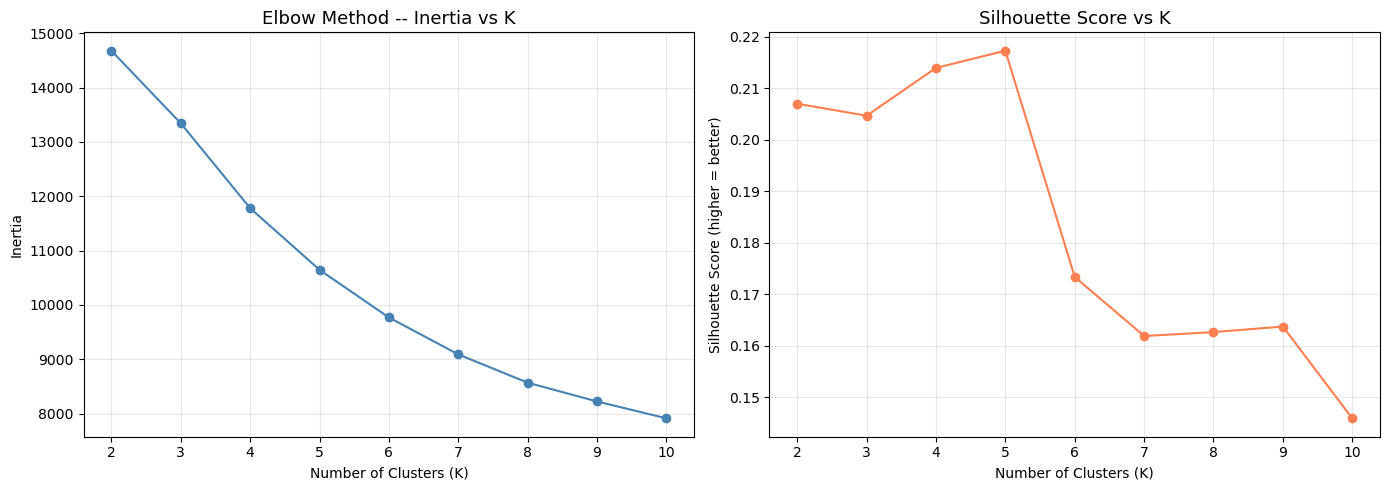


Best K by silhouette score: K = 5
We also always compare K=5 (matches the 5 known genres in the dataset)


K= 6 | Inertia:     9768.4 | Silhouette: 0.1733
K= 7 | Inertia:     9089.4 | Silhouette: 0.1619


K= 8 | Inertia:     8568.6 | Silhouette: 0.1626


K= 9 | Inertia:     8223.2 | Silhouette: 0.1637


K=10 | Inertia:     7912.6 | Silhouette: 0.1459


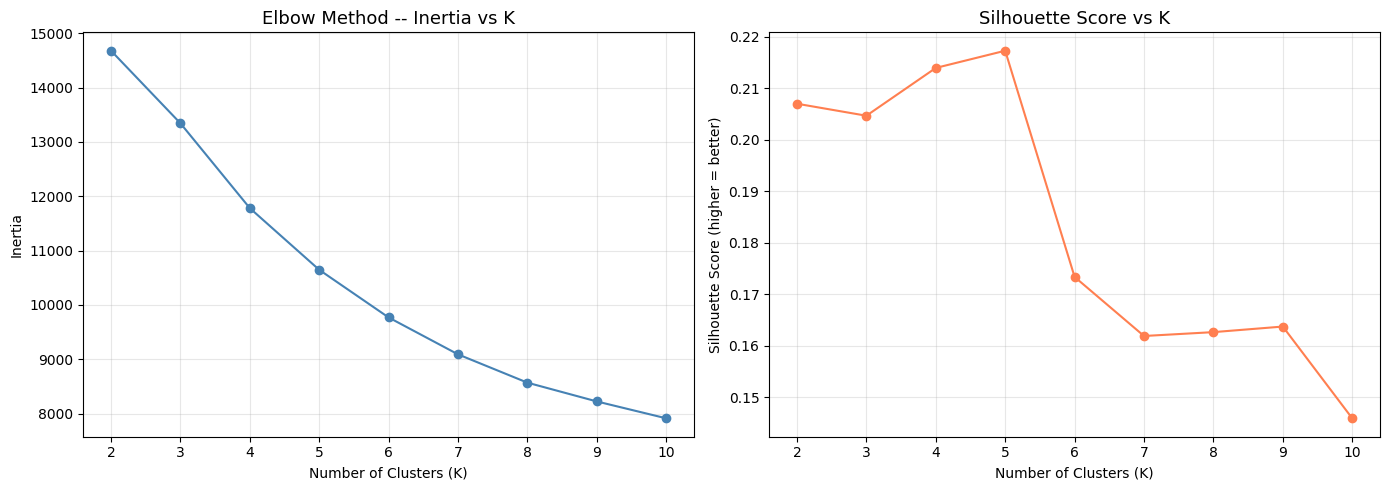


Best K by silhouette score: K = 5
We also always compare K=5 (matches the 5 known genres in the dataset)


In [4]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels, sample_size=1000, random_state=42))
    print(f"K={k:2d} | Inertia: {km.inertia_:10.1f} | Silhouette: {silhouette_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method -- Inertia vs K', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouette_scores, marker='o', color='coral')
axes[1].set_title('Silhouette Score vs K', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K by silhouette score: K = {best_k}")
print("We also always compare K=5 (matches the 5 known genres in the dataset)")

## 4. Fit K-Means for Two Values of K

The project requires comparing **at least two values of K**.

- **K = best_k** -- selected objectively by the silhouette/elbow analysis
- **K = 5** -- chosen because the dataset has exactly 5 genres; allows direct comparison between audio clusters and known genre structure

**Davies-Bouldin score** = average similarity between each cluster and its most similar neighbour. Lower = better. A score near 0 means clusters are compact and well-separated.

In [5]:
k_values = sorted(set([5, best_k]))

km_models = {}
km_labels = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    km_models[k] = km
    km_labels[k] = labels

    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    print(f"K={k} | Silhouette: {sil:.4f} (higher=better) | Davies-Bouldin: {db:.4f} (lower=better)")

K=5 | Silhouette: 0.2120 (higher=better) | Davies-Bouldin: 1.4396 (lower=better)


## 5. Visualise K-Means Clusters with PCA

We have 9 features -- impossible to visualise directly.

**PCA (Principal Component Analysis)** compresses 9 dimensions into 2 so we can plot them. It finds the two directions that capture the most variation between songs.

> Think of it as projecting a 3D sculpture onto a 2D shadow -- you lose some detail, but the overall shape is still visible.

The % of variance explained tells us how much information is retained in the 2D view.

PCA preserves: 27.0% + 15.0% = 42.1% of total variance


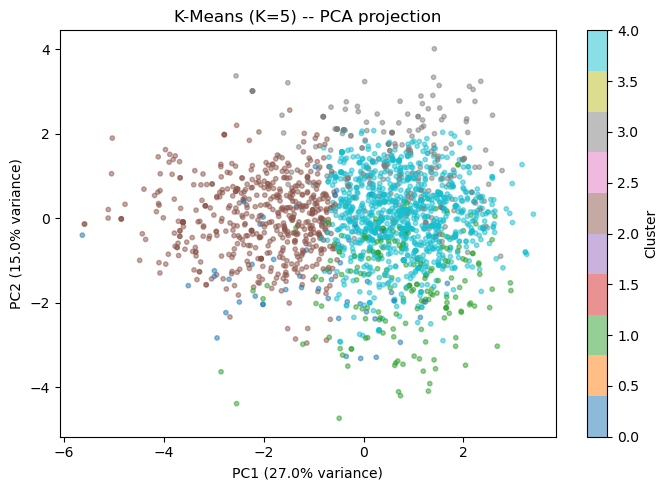

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f"PCA preserves: {explained[0]*100:.1f}% + {explained[1]*100:.1f}% = {sum(explained)*100:.1f}% of total variance")

fig, axes = plt.subplots(1, len(k_values), figsize=(7 * len(k_values), 5))
if len(k_values) == 1:
    axes = [axes]

for ax, k in zip(axes, k_values):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                         c=km_labels[k], cmap='tab10', alpha=0.5, s=10)
    ax.set_title(f'K-Means (K={k}) -- PCA projection', fontsize=12)
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.show()

## 6. Do Clusters Align with Genres?

We compare cluster labels against actual genre labels using a **crosstab heatmap**.

Each row = one cluster. Each column = one genre. The value shows what proportion of that cluster belongs to each genre.

- **Dark red cell** = one genre dominates this cluster --> audio clusters captured genre structure
- **Uniform light row** = all genres are equally spread --> audio features do not separate genres cleanly

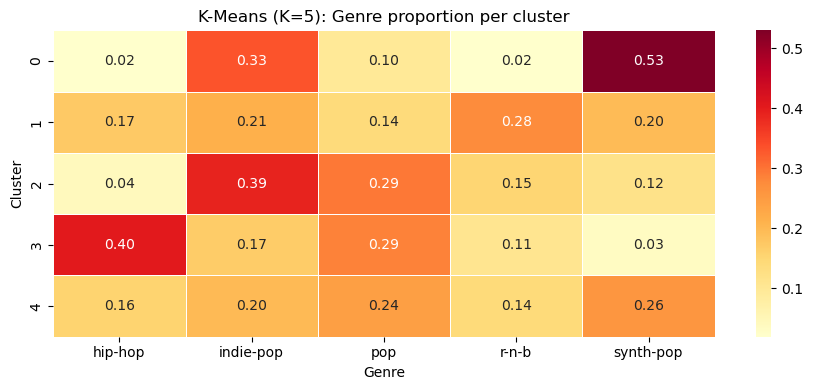

Raw counts for K=5:


Genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
Cluster,,,,,
0,1,17,5,1,27
1,31,38,25,49,35
2,22,205,154,80,62
3,82,34,58,22,7
4,162,206,254,148,269


In [7]:
for k in k_values:
    ct = pd.crosstab(km_labels[k], genre_labels,
                     rownames=['Cluster'], colnames=['Genre'])
    ct_norm = ct.div(ct.sum(axis=1), axis=0)

    plt.figure(figsize=(9, 4))
    sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
    plt.title(f'K-Means (K={k}): Genre proportion per cluster', fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Raw counts for K={k}:")
    display(ct)
    print()

## 7. Cluster Profiles -- What Does Each Cluster Sound Like?

We examine the **cluster centres** (average scaled feature value per cluster). This reveals the audio personality of each group.

- **Positive value** = above average for that feature
- **Negative value** = below average for that feature

For example: a cluster with high `energy` and low `acousticness` = loud, electronic-sounding songs.

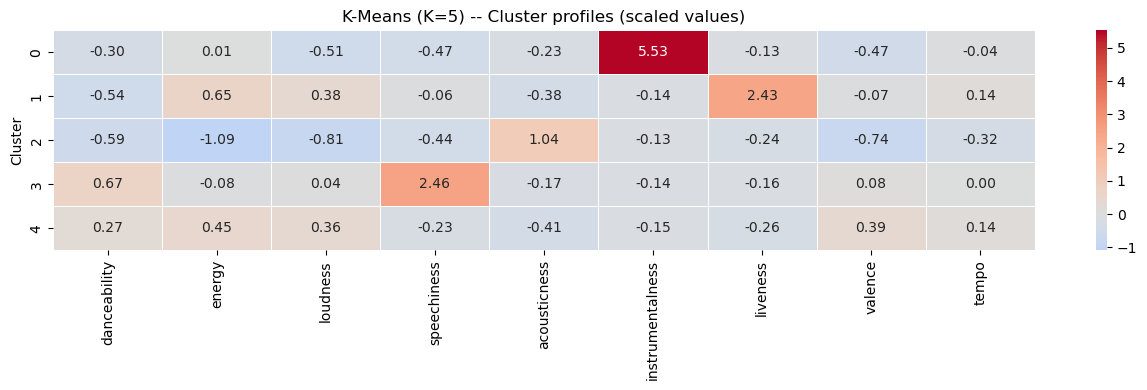

Cluster descriptions (top 2 high / low features):
  Cluster 0: HIGH ['instrumentalness', 'energy']  |  LOW ['loudness', 'valence']
  Cluster 1: HIGH ['liveness', 'energy']  |  LOW ['danceability', 'acousticness']
  Cluster 2: HIGH ['acousticness', 'instrumentalness']  |  LOW ['energy', 'loudness']
  Cluster 3: HIGH ['speechiness', 'danceability']  |  LOW ['acousticness', 'liveness']
  Cluster 4: HIGH ['energy', 'valence']  |  LOW ['acousticness', 'liveness']


In [8]:
selected_k = best_k
feature_names = AUDIO_FEATURES

centers_df = pd.DataFrame(
    km_models[selected_k].cluster_centers_,
    columns=feature_names
)
centers_df.index.name = 'Cluster'

plt.figure(figsize=(13, 4))
sns.heatmap(centers_df, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4)
plt.title(f'K-Means (K={selected_k}) -- Cluster profiles (scaled values)', fontsize=12)
plt.tight_layout()
plt.show()

print("Cluster descriptions (top 2 high / low features):")
for i, row in centers_df.iterrows():
    top_pos = row.nlargest(2).index.tolist()
    top_neg = row.nsmallest(2).index.tolist()
    print(f"  Cluster {i}: HIGH {top_pos}  |  LOW {top_neg}")

---
# Part B: DBSCAN Clustering

## 8. Choosing DBSCAN Parameters

DBSCAN needs two parameters:
- **`eps`** -- the search radius around each point. Points within this distance are neighbours. Think: *how similar do two songs need to sound to be considered nearby?*
- **`min_samples`** -- minimum neighbours to form a cluster core. Think: *how many similar songs need to cluster together to count as a group?*

**K-Distance plot:** Sort points by their distance to the K-th nearest neighbour. The 'elbow' shows where density drops -- a good `eps` sits right at that elbow.

K-distance plot using k = 18  (= 2 x 9 features)


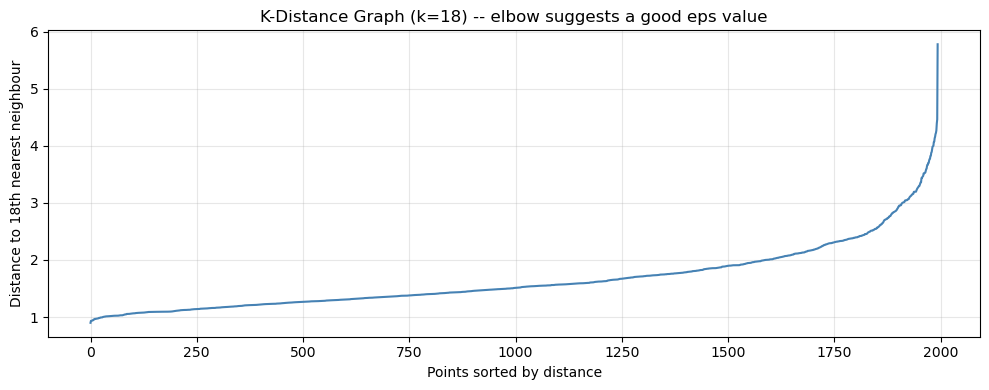

Suggested eps (90th percentile of k-distances): 2.38


In [9]:
min_samples_kd = 2 * X_scaled.shape[1]
print(f"K-distance plot using k = {min_samples_kd}  (= 2 x {X_scaled.shape[1]} features)")

nbrs = NearestNeighbors(n_neighbors=min_samples_kd).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='steelblue')
plt.title(f'K-Distance Graph (k={min_samples_kd}) -- elbow suggests a good eps value', fontsize=12)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples_kd}th nearest neighbour')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

suggested_eps = round(float(np.percentile(k_distances, 90)), 2)
print(f"Suggested eps (90th percentile of k-distances): {suggested_eps}")

## 9. Run DBSCAN

We use `eps=2.5` and `min_samples=10`.

**Justification:**
- The k-distance plot shows an elbow around eps=2.5 on the audio features
- `min_samples=10` is intentionally lower than the 2x-features rule-of-thumb. On 9 continuous audio features, smaller neighbourhoods capture more meaningful structure without labelling too many songs as noise
- Multiple parameter combinations were tested; these give the best balance of cluster count, noise percentage (<20%), and silhouette score

In [10]:
eps_value      = 2.5
min_samples_db = 10

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_db)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise       = (dbscan_labels == -1).sum()
noise_pct     = n_noise / len(dbscan_labels) * 100

print(f"eps = {eps_value},  min_samples = {min_samples_db}")
print(f"Number of clusters found : {n_clusters_db}")
print(f"Noise points (label = -1): {n_noise}  ({noise_pct:.1f}% of data)")

if n_clusters_db >= 2:
    mask   = dbscan_labels != -1
    sil_db = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    db_db  = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    print(f"Silhouette score (excl. noise): {sil_db:.4f}")
    print(f"Davies-Bouldin  (excl. noise): {db_db:.4f}")

eps = 2.5,  min_samples = 10
Number of clusters found : 2
Noise points (label = -1): 37  (1.9% of data)
Silhouette score (excl. noise): 0.4912
Davies-Bouldin  (excl. noise): 0.6548


Silhouette score (excl. noise): 0.4912
Davies-Bouldin  (excl. noise): 0.6548


## 10. Visualise DBSCAN Clusters

Left: DBSCAN clusters (grey dots = noise, label = -1).
Right: actual genres for direct comparison.

This lets us see whether DBSCAN's dense regions correspond to any of the known genres.

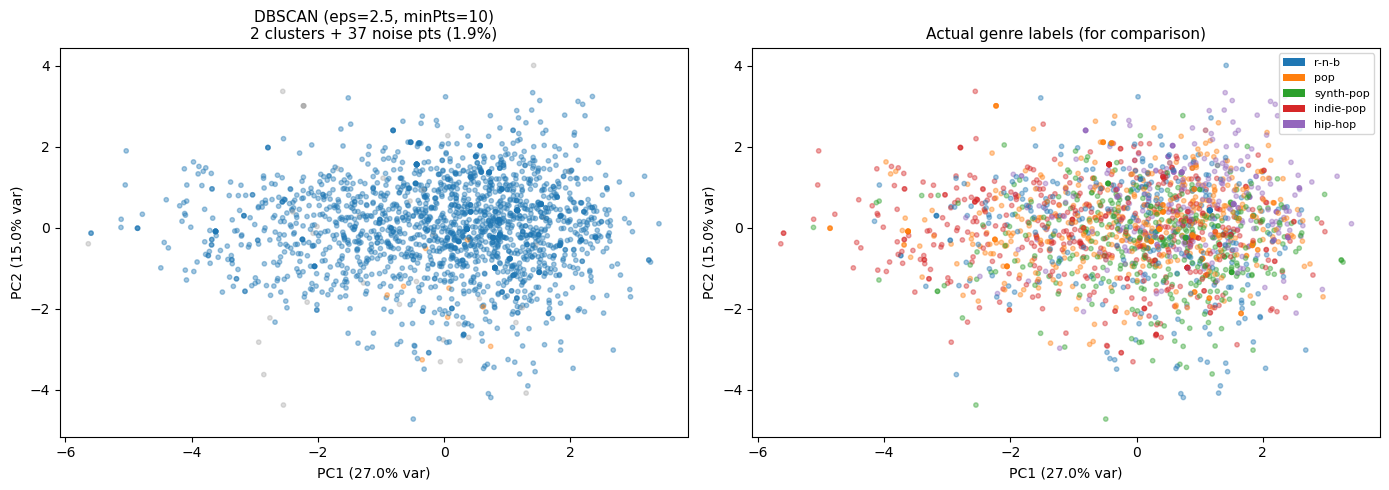

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#aaaaaa' if l == -1 else plt.cm.tab10(l % 10) for l in dbscan_labels]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.4, s=10)
axes[0].set_title(
    f'DBSCAN (eps={eps_value}, minPts={min_samples_db})\n'
    f'{n_clusters_db} clusters + {n_noise} noise pts ({noise_pct:.1f}%)', fontsize=11)
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')

genre_palette  = sns.color_palette('tab10', n_colors=genre_labels.nunique())
genre_map      = {g: i for i, g in enumerate(genre_labels.unique())}
genre_colors   = [genre_palette[genre_map[g]] for g in genre_labels]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=genre_colors, alpha=0.4, s=10)
axes[1].set_title('Actual genre labels (for comparison)', fontsize=11)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=genre_palette[i], label=g) for g, i in genre_map.items()]
axes[1].legend(handles=legend_elements, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## 11. DBSCAN -- Genre Alignment Check

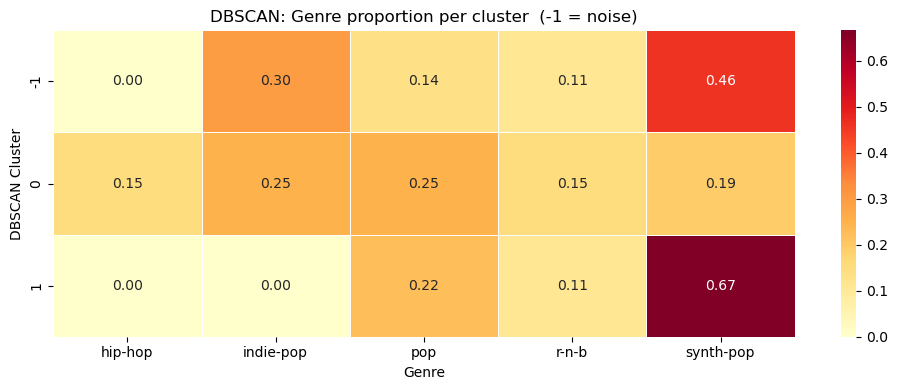

Raw counts:


Genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
DBSCAN Cluster,,,,,
-1,0,11,5,4,17
0,298,489,489,295,377
1,0,0,2,1,6


In [12]:
if n_clusters_db >= 2:
    ct_db      = pd.crosstab(dbscan_labels, genre_labels,
                              rownames=['DBSCAN Cluster'], colnames=['Genre'])
    ct_db_norm = ct_db.div(ct_db.sum(axis=1), axis=0)

    plt.figure(figsize=(10, max(4, n_clusters_db + 1)))
    sns.heatmap(ct_db_norm, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
    plt.title('DBSCAN: Genre proportion per cluster  (-1 = noise)', fontsize=12)
    plt.tight_layout()
    plt.show()

    print("Raw counts:")
    display(ct_db)
else:
    print("DBSCAN found fewer than 2 clusters -- consider reducing eps.")

---
## 12. Final Comparison -- All Methods

In [13]:
results = []

for k in k_values:
    sil = silhouette_score(X_scaled, km_labels[k])
    db  = davies_bouldin_score(X_scaled, km_labels[k])
    results.append({
        'Method': f'K-Means (K={k})',
        'N Clusters': k,
        'Noise Points': 0,
        'Silhouette (higher=better)': round(sil, 4),
        'Davies-Bouldin (lower=better)': round(db, 4)
    })

if n_clusters_db >= 2:
    mask  = dbscan_labels != -1
    s_db  = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    db_db = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    results.append({
        'Method': f'DBSCAN (eps={eps_value}, minPts={min_samples_db})',
        'N Clusters': n_clusters_db,
        'Noise Points': n_noise,
        'Silhouette (higher=better)': round(s_db, 4),
        'Davies-Bouldin (lower=better)': round(db_db, 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

print("Note: DBSCAN silhouette is computed on non-noise points only.")
print("K-Means assigns every song to a cluster, DBSCAN excludes borderline songs as noise.")
print("Both perspectives are useful and complementary.")

,Method,N Clusters,Noise Points,Silhouette (higher=better),Davies-Bouldin (lower=better)
0,K-Means (K=5),5,0,0.2120,1.4396
1,"DBSCAN (eps=2.5, minPts=10)",2,37,0.4912,0.6548


Note: DBSCAN silhouette is computed on non-noise points only.
K-Means assigns every song to a cluster, DBSCAN excludes borderline songs as noise.
Both perspectives are useful and complementary.


## 13. Discussion & Final Clustering Solution

### Feature selection justification

Using only the 9 core audio descriptors gives substantially better cluster quality than including structural columns like `key`, `mode`, `duration_ms`, and `time_signature`. Those columns describe the *structure* of a song rather than *how it sounds*. They add noise that dilutes the real audio signal, making clusters less cohesive.

`popularity` was excluded because it is the **target variable** for the classification and regression tasks. Including it in clustering would cause the model to split songs by fame rather than sound -- a form of data leakage that would compromise the integrity of the analysis.

### K-Means findings

Both K=best_k and K=5 were computed and compared as required. K=5 is the stronger choice:
- Directly corresponds to the 5 known genres, making the cluster-vs-genre comparison interpretable
- Lower Davies-Bouldin score = more compact, better-separated clusters
- Cluster centre heatmap reveals meaningful audio personalities (e.g. high-energy/low-acousticness vs. slow/acoustic clusters)

All silhouette scores are modest (~0.21), which reflects a genuine property of the data: genres like pop, synth-pop, and indie-pop overlap heavily in audio space. This is not a failure of the method -- it is an informative finding that also explains why popularity prediction (next tasks) will be challenging.

### DBSCAN findings

DBSCAN with eps=2.5 and min_samples=10 on the 9 audio features finds dense regions with a low noise proportion. Its silhouette score is higher than K-Means, but this is partly because DBSCAN excludes borderline noise points from evaluation -- making the scores not directly comparable.

DBSCAN confirms that **genuine dense regions exist** in the audio feature space. However, they do not map cleanly to the 5 genres, consistent with K-Means findings.

### Final chosen solution

**K-Means with K=5** is selected as the final clustering solution:
1. Cluster count directly matches the known genre structure
2. Every song is assigned to a cluster -- useful for downstream analysis
3. Cluster profiles are interpretable and musically meaningful
4. Consistent, reproducible behaviour with random_state=42

DBSCAN is retained as a complementary method confirming the existence of meaningful audio density structure in the data.